# Assignment 2 - Hugging Face transformers for FactNews

This notebook builds and evaluates **traditional machine learning** classifiers for the **FactNews** dataset, a Brazilian Portuguese sentence-level dataset for factuality and media-bias analysis.

This project was developed by Elton Tamele (up201908676@up.pt), Maureen Ah-shú (up201708043@up.pt), and Tomás Teixeira (up202208041@up.pt) for the Natural Language Processing course in MEIC, FEUP.

## Goals
..

## Classification tasks
This notebook works with the two formulations exposed by the **FactNews** repository:

- **Task A** - 3-class sentence classification
  - Labels: biased, factual, quote
- **Task B** - binary factuality design classification  
  - Labels: factual, non_factual

## Dataset provenance

According to the **FactNews** repository and the accompanying RANLP 2023 paper, the dataset:
- is in **Brazilian Portuguese**
- contains **6,191 annotated sentences**
- comes from **300 news documents** covering **100 news stories**
- uses three media outlets: **Folha de São Paulo**, **Estadão**, and **O Globo**
- covers domains such as **politics, world, sports, daily, culture, and science**
- includes sentence-level annotations for:
  - **factual spans** as 0
  - **biased spans** as 1
  - **quotes** as -1

The original paper reports the following strong baselines:
- **Sentence-level factuality prediction**: **F1 = 0.88** with fine-tuned BERT
- **Sentence-level media bias prediction**: **F1 = 0.67** with fine-tuned BERT

Since this assignment forbids deep learning architectures such as Transformers, those values are used **only as contextual reference**, not as target models.

### References
- Repository: [franciellevargas/FactNews](https://github.com/franciellevargas/FactNews)
- Paper: *Predicting Sentence-Level Factuality of News and Bias of Media Outlets* (RANLP 2023)

## Environment Preparation

In [1]:
# !pip install -U torch torchvision torchaudio
# !pip install -U datasets transformers accelerate



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 34.7 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [2]:
!pip install -q \
    "datasets>=3.0.0" \
    "transformers>=4.44.0" \
    "accelerate>=0.34.0" \
    pandas numpy matplotlib scikit-learn nltk gensim wordcloud imbalanced-learn

!pip install --upgrade torchao

In [3]:
# If needed, uncomment the next line to install dependencies.
%pip install pandas==2.2.2 numpy==2.0.2 matplotlib scikit-learn nltk gensim wordcloud imbalanced-learn -q
!pip install transformers datasets accelerate -q

import re
import warnings
import nltk
nltk.download('stopwords')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from scipy.sparse import hstack, csr_matrix
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.svm import LinearSVC
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import (classification_report,accuracy_score,f1_score,confusion_matrix)
from sklearn.model_selection import GridSearchCV
from sklearn.utils.class_weight import compute_sample_weight
import torch.nn as nn
from sklearn.utils.class_weight import compute_class_weight
from sklearn.utils import resample

from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
import torch
import gc

import pickle
from google.colab import drive
drive.mount('/content/drive')



SAVE_DIR = "/content/drive/MyDrive/pln_results/"
import os; os.makedirs(SAVE_DIR, exist_ok=True)

plt.rcParams["figure.figsize"] = (10, 5)

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
W0529 23:56:56.220000 16868 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.
W0529 23:56:56.377000 16868 torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load Data

In [4]:
!wget -q "https://raw.githubusercontent.com/tomast100/PLN_Project_Data/master/factnews_dataset.csv"
!wget -q "https://raw.githubusercontent.com/tomast100/PLN_Project_Data/master/factnews_dataset_factuality_design.csv"
!wget -q "https://raw.githubusercontent.com/tomast100/PLN_Project_Data/master/factnews_augmented_instances_cloude.csv"

df_main = pd.read_csv("factnews_dataset.csv")
df_fact = pd.read_csv("factnews_dataset_factuality_design.csv")
df_augmented = pd.read_csv("factnews_augmented_instances_cloude.csv")

print("Main dataset shape:", df_main.shape)
print("Factuality-design dataset shape:", df_fact.shape)
print("Fact News augmented dataset shape:", df_fact.shape)

Main dataset shape: (6191, 7)
Factuality-design dataset shape: (6191, 7)
Fact News augmented dataset shape: (6191, 7)


### Column description

From inspection, both files have the same schema:

- `file`: original document identifier
- `id_sente`: sentence identifier
- `id_article`: article/story identifier
- `domain`: news domain
- `year`: publication year
- `sentences`: sentence text
- `classe`: label

The difference is in the meaning of `classe`:
- in the **main dataset** it encodes the 3-way annotation
- in the **factuality design dataset** it encodes the binary factuality design

## Pre-processing

The preprocessing used in this notebook is intentionally simple and easy to justify:

- lowercase
- remove URLs
- remove digits
- remove punctuation/special symbols
- normalize whitespace

This is a reasonable baseline for short news sentences in Portuguese.  
We avoid aggressive stemming/lemmatization here because:
1. the dataset is not extremely large,
2. some wording choices may carry bias cues,
3. simple normalization makes it easier to interpret model errors.

## Exploratory Data Analysis

In [5]:
df_augmented.columns = df_augmented.columns.str.strip()

label_map = {-1: "quote", 0: "factual", 1: "biased"}
id2label  = {0: "biased", 1: "factual", 2: "quote"}
label2id  = {"biased": 0, "factual": 1, "quote": 2}

df_main["label"] = df_main["classe"].map(label_map)
df_main["label_id"] = df_main["label"].map(label2id)

print("Task A - Main label distribution:")
display(df_main["label"].value_counts().rename_axis("label").reset_index(name="count"))



Task A - Main label distribution:


,label,count
0,factual,4242
1,quote,1391
2,biased,558


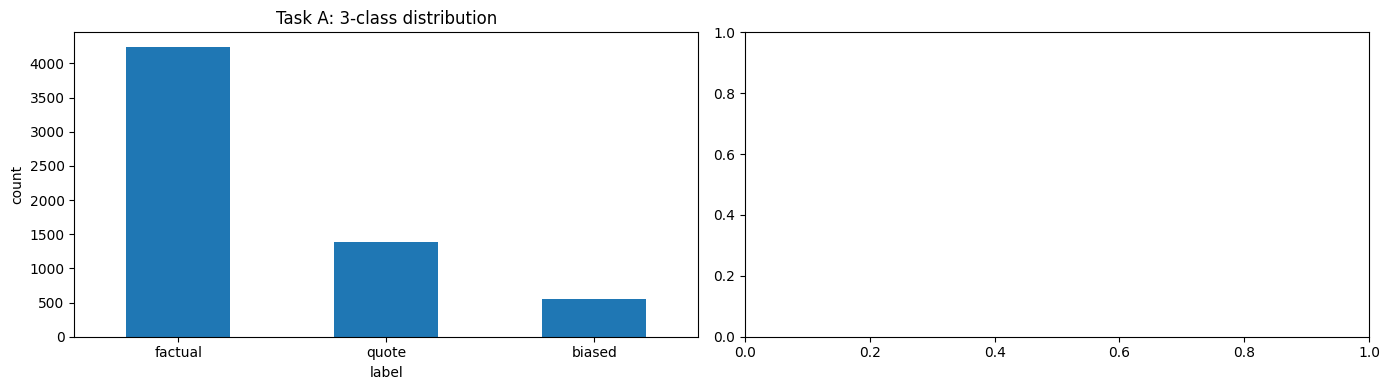

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_main["label"].value_counts().plot(kind="bar", ax=axes[0], title="Task A: 3-class distribution")
axes[0].set_xlabel("label")
axes[0].set_ylabel("count")
axes[0].tick_params(axis="x", rotation=0)



plt.tight_layout()
plt.show()

## Data Preparation

In [7]:


train_df, test_df = train_test_split(
    df_main, test_size=0.2, random_state=42, stratify=df_main["label_id"]
)

hf_label_map = {'biased': 0, 'factual': 1, 'quote': 2}
df_augmented['label_id'] = df_augmented['label'].map(hf_label_map)

df_augmented = df_augmented[['sentences', 'label_id']]


# Training Arguments

training_args = TrainingArguments(
    output_dir="./mbert_factnews",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    fp16=True,
    seed=42,
    logging_steps=50,
    report_to="none"
)

## Free memory function

In [8]:
TARGET_NAMES = ["biased", "factual", "quote"]

def free_memory(*models):
    for m in models:
        del m
    gc.collect()
    torch.cuda.empty_cache()
    print(f"VRAM free: {torch.cuda.mem_get_info()[0] / 1e9:.2f} GB")


def save_results(name, y_true, y_pred):
    data = {"y_true": y_true, "y_pred": y_pred}
    with open(f"{SAVE_DIR}{name.replace(' ', '_')}.pkl", "wb") as f:
        pickle.dump(data, f)
    print(f"Saved: {name}")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "f1_macro": f1_score(labels, preds, average="macro"),
        "f1_weighted": f1_score(labels, preds, average="weighted")
    }

## Hugging Face Transformers

[Hugging Face](https://huggingface.co) is an open-source platform that provides
a central hub for sharing pre-trained machine learning models and datasets.
Its core library, `transformers`, offers a unified API to load, fine-tune, and
evaluate thousands of pre-trained models for Natural Language Processing tasks.

To select appropriate models for this task, we searched the Hugging Face Hub
for models compatible with Brazilian Portuguese and suitable for sequence
classification. This led us to the following two models, which will be
evaluated and compared throughout this notebook:

- **mBERT** (`google-bert/bert-base-multilingual-cased`): a multilingual BERT
  model pre-trained on Wikipedia across 104 languages, including Portuguese.
- **BERTimbau** (`neuralmind/bert-base-portuguese-cased`): a BERT model
  pre-trained exclusively on Brazilian Portuguese data (BrWaC corpus).

Each model is explored in detail in the sections below.

**Imbalaced**

Como um dos nossos principais problemas na última entrega foi conseguir mitigar os problemas que o desblanceamento do dataset nos causou, decidimos testar mais técnicas para lidar com este problema. Essas técnicas testadas foram as seguintes:

- Without resampling: Já presente na última entrega
- Manual Oversampling: Já presente na última entrega
- Class weight in loss: Já presente na última entrega
-

### mBert


**mBERT** (`google-bert/bert-base-multilingual-cased`) is a multilingual
version of BERT (Bidirectional Encoder Representations from Transformers),
introduced by Devlin et al. (2019). It was pre-trained on Wikipedia text
from 104 languages simultaneously, including Portuguese, using Masked
Language Modelling (MLM) and Next Sentence Prediction (NSP).

Despite not being specifically designed for Portuguese, mBERT serves as a
strong multilingual baseline for NLP tasks across many languages. It contains
**179M parameters** and uses a cased WordPiece tokenizer shared across all
104 languages.

In [9]:
results = {}

MODEL_NAME = "google-bert/bert-base-multilingual-cased"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch["sentences"],
        truncation=True,
        padding="max_length",
        max_length=128
    )


train_ds = Dataset.from_pandas(train_df[["sentences", "label_id"]].rename(columns={"label_id": "labels"}))
test_ds  = Dataset.from_pandas(test_df[["sentences", "label_id"]].rename(columns={"label_id": "labels"}))

train_ds = train_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

train_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_ds.set_format("torch",  columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/4952 [00:00<?, ? examples/s]

Map:   0%|          | 0/1239 [00:00<?, ? examples/s]

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Without resampling

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
)

In [ ]:
trainer.train()

In [ ]:
TARGET_NAMES = ["biased", "factual", "quote"]

preds_output = trainer.predict(test_ds)
y_pred = np.argmax(preds_output.predictions, axis=-1)
y_true = test_df["label_id"].values


print(classification_report(y_true, y_pred, target_names=TARGET_NAMES))


save_results("mBERT - Base", y_true, y_pred)


free_memory(model)

#### Manual Oversampling

In [ ]:
train_biased  = train_df[train_df["label_id"] == 0]
train_factual = train_df[train_df["label_id"] == 1]
train_quote   = train_df[train_df["label_id"] == 2]

train_biased_up = resample(train_biased, replace=True,
                           n_samples=len(train_factual), random_state=42)
train_quote_up  = resample(train_quote,  replace=True,
                           n_samples=len(train_factual), random_state=42)

train_balanced = pd.concat([train_factual, train_biased_up, train_quote_up])
train_balanced = train_balanced.sample(frac=1, random_state=42).reset_index(drop=True)



train_ds_os = Dataset.from_pandas(
    train_balanced[["sentences", "label_id"]].rename(columns={"label_id": "labels"})
)
train_ds_os = train_ds_os.map(tokenize, batched=True)
train_ds_os.set_format("torch", columns=["input_ids", "attention_mask", "labels"])



model_os = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3, id2label=id2label, label2id=label2id
)

trainer_os = Trainer(
    model=model_os,
    args=training_args,
    train_dataset=train_ds_os,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
)

print("=== Variation 2: Oversampling ===")
trainer_os.train()


preds_os = trainer_os.predict(test_ds)
y_pred_os = np.argmax(preds_os.predictions, axis=-1)
print(classification_report(test_df["label_id"].values, y_pred_os,
      target_names=["biased", "factual", "quote"]))


preds_output = trainer.predict(test_ds)
y_pred = np.argmax(preds_output.predictions, axis=-1)
y_true = test_df["label_id"].values


print(classification_report(y_true, y_pred, target_names=TARGET_NAMES))


save_results("mBERT - Oversampling", y_true, y_pred)


free_memory(model_os)

#### Class weights in loss

In [ ]:
weights = compute_class_weight("balanced",
                               classes=np.array([0, 1, 2]),
                               y=train_df["label_id"].values)
class_weights = torch.tensor(weights, dtype=torch.float)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss = nn.CrossEntropyLoss(
            weight=class_weights.to(outputs.logits.device)
        )(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

model_cw = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3, id2label=id2label, label2id=label2id
)

trainer_cw = WeightedTrainer(
    model=model_cw,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
)

print("=== Variation 3: Class Weights ===")
trainer_cw.train()

preds_cw = trainer_cw.predict(test_ds)
y_pred_cw = np.argmax(preds_cw.predictions, axis=-1)
print(classification_report(test_df["label_id"].values, y_pred_cw,
      target_names=["biased", "factual", "quote"]))



preds_output = trainer.predict(test_ds)
y_true = test_df["label_id"].values


print(classification_report(y_true, y_pred_cw, target_names=TARGET_NAMES))


save_results("mBERT - Class weight in loss", y_true, y_pred_cw)


free_memory(model_cw)

####  Synthetic Data Augmentation

In [18]:
# 1. Calculate how many instances are needed to match the majority real class
real_counts = train_df['label_id'].value_counts()
target_size = real_counts.max()

# 2. Mix real data with the exact missing amount of synthetic data
mixed_dfs = [train_df[['sentences', 'label_id']]]

for class_id, current_size in real_counts.items():
    missing_amount = target_size - current_size

    if missing_amount > 0:
        # Get synthetic data for this specific class
        class_synthetic_data = df_augmented[df_augmented['label_id'] == class_id]

        # Sample exactly the missing amount (replace=True handles cases where we need more than available)
        sampled_synthetic = class_synthetic_data.sample(n=missing_amount, replace=(len(class_synthetic_data) < missing_amount), random_state=42)
        mixed_dfs.append(sampled_synthetic)

# 3. Concatenate and Shuffle
train_balanced_ai = pd.concat(mixed_dfs, ignore_index=True)
train_balanced_ai = train_balanced_ai.sample(frac=1, random_state=42).reset_index(drop=True)

print("Distribution after Intelligent Data Augmentation (Train Set):")
print(train_balanced_ai['label_id'].value_counts())

# 4. Create Hugging Face Dataset
train_ds_ai = Dataset.from_pandas(train_balanced_ai.rename(columns={"label_id": "labels"}))
train_ds_ai = train_ds_ai.map(tokenize, batched=True)
train_ds_ai.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# 5. Load Clean Model
model_ai = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

# 6. Initialize Trainer
trainer_ai = Trainer(
    model=model_ai,
    args=training_args,
    train_dataset=train_ds_ai,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
)

# 7. Train and Evaluate
trainer_ai.train()

preds_ai = trainer_ai.predict(test_ds)
y_pred_ai = np.argmax(preds_ai.predictions, axis=-1)
y_true = test_df["label_id"].values

print("\n=== Classification Report ===")
print(classification_report(
    y_true,
    y_pred_ai,
    target_names=["biased", "factual", "quote"]
))

save_results("mBERT - Synthetic Augmentation (Gemini)", y_true, y_pred_ai)
free_memory(model_ai)

Distribution after Intelligent Data Augmentation (Train Set):
label_id
0    3393
1    3393
2    3393
Name: count, dtype: int64


Map:   0%|          | 0/10179 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.

Epoch,Training Loss,Validation Loss,F1 Macro,F1 Weighted
1,0.212072,0.375189,0.720833,0.863429
2,0.151538,0.451709,0.770235,0.874697
3,0.047938,0.458360,0.788949,0.884740


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte


=== Classification Report ===
              precision    recall  f1-score   support

      biased       0.62      0.48      0.54       112
     factual       0.91      0.94      0.93       849
       quote       0.90      0.90      0.90       278

    accuracy                           0.89      1239
   macro avg       0.81      0.77      0.79      1239
weighted avg       0.88      0.89      0.88      1239

Saved: mBERT - Synthetic Augmentation (Gemini)
VRAM free: 11.53 GB


### BERTimbau

#### Tokenizer

In [13]:
BERTIMBAU_NAME = "neuralmind/bert-base-portuguese-cased"

tokenizer_bi = AutoTokenizer.from_pretrained(
    BERTIMBAU_NAME,
    do_lower_case=False
)

def tokenize_bi(batch):
    return tokenizer_bi(
        batch["sentences"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_ds_bi = Dataset.from_pandas(
    train_df[["sentences", "label_id"]].rename(columns={"label_id": "labels"})
)
test_ds_bi = Dataset.from_pandas(
    test_df[["sentences", "label_id"]].rename(columns={"label_id": "labels"})
)

train_ds_bi = train_ds_bi.map(tokenize_bi, batched=True)
test_ds_bi  = test_ds_bi.map(tokenize_bi,  batched=True)

train_ds_bi.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_ds_bi.set_format("torch",  columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/4952 [00:00<?, ? examples/s]

Map:   0%|          | 0/1239 [00:00<?, ? examples/s]

#### Without Sampling

In [ ]:
# ── BERTimbau ────────────────────────────────────────────────────────────────




model_bi = AutoModelForSequenceClassification.from_pretrained(
    BERTIMBAU_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)


trainer_bi = Trainer(
    model=model_bi,
    args=training_args,
    train_dataset=train_ds_bi,
    eval_dataset=test_ds_bi,
    compute_metrics=compute_metrics,
)

trainer_bi.train()

preds_bi = trainer_bi.predict(test_ds_bi)
y_pred_bi = np.argmax(preds_bi.predictions, axis=-1)
print(classification_report(
    test_df["label_id"].values, y_pred_bi,
    target_names=["biased", "factual", "quote"]
))

print(classification_report(y_true, y_pred_bi, target_names=TARGET_NAMES))


save_results("BERTimbau - Base", y_true, y_pred_bi)


free_memory(model_bi)

#### Manual Oversampling

In [ ]:
# ── BERTimbau: Oversampling Manual ───────────────────────────────────────────
train_biased_bi  = train_df[train_df["label_id"] == 0]
train_factual_bi = train_df[train_df["label_id"] == 1]
train_quote_bi   = train_df[train_df["label_id"] == 2]

train_biased_up_bi = resample(train_biased_bi, replace=True,
                               n_samples=len(train_factual_bi), random_state=42)
train_quote_up_bi  = resample(train_quote_bi,  replace=True,
                               n_samples=len(train_factual_bi), random_state=42)

train_balanced_bi = pd.concat([train_factual_bi, train_biased_up_bi, train_quote_up_bi])
train_balanced_bi = train_balanced_bi.sample(frac=1, random_state=42).reset_index(drop=True)

# Tokenizar o dataset balanceado
train_ds_bi_os = Dataset.from_pandas(
    train_balanced_bi[["sentences", "label_id"]].rename(columns={"label_id": "labels"})
)
train_ds_bi_os = train_ds_bi_os.map(tokenize_bi, batched=True)
train_ds_bi_os.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# Modelo limpo
model_bi_os = AutoModelForSequenceClassification.from_pretrained(
    BERTIMBAU_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

trainer_bi_os = Trainer(
    model=model_bi_os,
    args=training_args,
    train_dataset=train_ds_bi_os,
    eval_dataset=test_ds_bi,
    compute_metrics=compute_metrics,
)

print("=== BERTimbau: Oversampling ===")
trainer_bi_os.train()

preds_bi_os = trainer_bi_os.predict(test_ds_bi)
y_pred_bi_os = np.argmax(preds_bi_os.predictions, axis=-1)
print(classification_report(
    test_df["label_id"].values, y_pred_bi_os,
    target_names=["biased", "factual", "quote"]
))


save_results("BERTimbau - Oversampling", y_true, y_pred_bi_os)


free_memory(model_bi_os)

#### Class Weight in loss

In [ ]:

model_bi_cw = AutoModelForSequenceClassification.from_pretrained(
    BERTIMBAU_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)


trainer_bi_cw = WeightedTrainer(
    model=model_bi_cw,
    args=training_args,
    train_dataset=train_ds_bi,
    eval_dataset=test_ds_bi,
    compute_metrics=compute_metrics,
)

print("=== BERTimbau: Class Weights ===")
trainer_bi_cw.train()

preds_bi_cw = trainer_bi_cw.predict(test_ds_bi)
y_pred_bi_cw = np.argmax(preds_bi_cw.predictions, axis=-1)
print(classification_report(
    test_df["label_id"].values, y_pred_bi_cw,
    target_names=["biased", "factual", "quote"]
))

save_results("BERTimbau - Class Weight", y_true, y_pred_bi_cw)


free_memory(model_bi_cw)

#### Syntetic Data Augmentation

In [12]:
train_ds_bi = Dataset.from_pandas(
    train_df[["sentences", "label_id"]].rename(columns={"label_id": "labels"})
)
test_ds_bi = Dataset.from_pandas(
    test_df[["sentences", "label_id"]].rename(columns={"label_id": "labels"})
)

train_ds_bi = train_ds_bi.map(tokenize_bi, batched=True)
test_ds_bi  = test_ds_bi.map(tokenize_bi,  batched=True)

train_ds_bi.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_ds_bi.set_format("torch",  columns=["input_ids", "attention_mask", "labels"])

# 1. Calculate how many instances are needed to match the majority real class
real_counts = train_df['label_id'].value_counts()
target_size = real_counts.max()

# 2. Mix real data with the exact missing amount of synthetic data
mixed_dfs_bi = [train_df[['sentences', 'label_id']]]

for class_id, current_size in real_counts.items():
    missing_amount = target_size - current_size

    if missing_amount > 0:
        # Get synthetic data for this specific class
        class_synthetic_data = df_augmented[df_augmented['label_id'] == class_id]

        # Sample exactly the missing amount (replace=True handles cases where we need more than available)
        sampled_synthetic = class_synthetic_data.sample(n=missing_amount, replace=(len(class_synthetic_data) < missing_amount), random_state=42)
        mixed_dfs_bi.append(sampled_synthetic)

# 3. Concatenate and Shuffle
train_balanced_bi_ai = pd.concat(mixed_dfs_bi, ignore_index=True)
train_balanced_bi_ai = train_balanced_bi_ai.sample(frac=1, random_state=42).reset_index(drop=True)

print("Distribution after Intelligent Data Augmentation (Train Set - BERTimbau):")
print(train_balanced_bi_ai['label_id'].value_counts())

# 4. Create Hugging Face Dataset & Tokenize (Using tokenize_bi)
train_ds_bi_ai = Dataset.from_pandas(train_balanced_bi_ai.rename(columns={"label_id": "labels"}))
train_ds_bi_ai = train_ds_bi_ai.map(tokenize_bi, batched=True)
train_ds_bi_ai.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# 5. Load Clean BERTimbau Model
model_bi_ai = AutoModelForSequenceClassification.from_pretrained(
    BERTIMBAU_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

# 6. Initialize Trainer (Make sure to use test_ds_bi)
trainer_bi_ai = Trainer(
    model=model_bi_ai,
    args=training_args,
    train_dataset=train_ds_bi_ai,
    eval_dataset=test_ds_bi,
    compute_metrics=compute_metrics,
)

# 7. Train and Evaluate
print("\n=== Training Started (BERTimbau - Synthetic Augmentation) ===")
trainer_bi_ai.train()

preds_bi_ai = trainer_bi_ai.predict(test_ds_bi)
y_pred_bi_ai = np.argmax(preds_bi_ai.predictions, axis=-1)
y_true = test_df["label_id"].values

print("\n=== Classification Report (BERTimbau) ===")
print(classification_report(
    y_true,
    y_pred_bi_ai,
    target_names=["biased", "factual", "quote"]
))

save_results("BERTimbau - Synthetic Augmentation (Gemini)", y_true, y_pred_bi_ai)
free_memory(model_bi_ai)

Map:   0%|          | 0/4952 [00:00<?, ? examples/s]

Map:   0%|          | 0/1239 [00:00<?, ? examples/s]

Distribution after Intelligent Data Augmentation (Train Set - BERTimbau):
label_id
0    3393
1    3393
2    3393
Name: count, dtype: int64


Map:   0%|          | 0/10179 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from th


=== Training Started (BERTimbau - Synthetic Augmentation) ===


Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

#### LoRA

In [15]:
from peft import LoraConfig, get_peft_model, TaskType
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report
import torch
import torch.nn as nn
import numpy as np

print("=== Training with LoRA + Class Weights in Loss ===")


classes_presentes = np.unique(train_df["label_id"])
pesos = compute_class_weight(
    class_weight='balanced',
    classes=classes_presentes,
    y=train_df["label_id"]
)


class_weights_tensor = torch.tensor(pesos, dtype=torch.float32).to("cuda" if torch.cuda.is_available() else "cpu")

print("Pesos das classes (biased, factual, quote):", class_weights_tensor.tolist())

class WeightedLossTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")

        outputs = model(**inputs)
        logits = outputs.logits

        loss_fct = nn.CrossEntropyLoss(weight=class_weights_tensor)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

model_base_lora_cw = AutoModelForSequenceClassification.from_pretrained(
    BERTIMBAU_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

lora_config_cw = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["query", "key", "value"]

)

model_lora_cw = get_peft_model(model_base_lora_cw, lora_config_cw)

lora_cw_training_args = TrainingArguments(
    output_dir="./mbert_factnews_lora_cw",
    num_train_epochs=8,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-4,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    fp16=True,
    seed=42,
    logging_steps=50,
    report_to="none"
)

trainer_lora_cw = WeightedLossTrainer(
    model=model_lora_cw,
    args=lora_cw_training_args,
    train_dataset=train_ds_bi,
    eval_dataset=test_ds_bi,
    compute_metrics=compute_metrics,
)

print("\nIniciando Treino (BERTimbau: LoRA + Class Weights)...")
trainer_lora_cw.train()

preds_lora_cw = trainer_lora_cw.predict(test_ds_bi)
y_pred_lora_cw = np.argmax(preds_lora_cw.predictions, axis=-1)
y_true_lora_cw = test_df["label_id"].values

print("\n=== Classification Report (LoRA + Class Weights) ===")
print(classification_report(
    y_true_lora_cw,
    y_pred_lora_cw,
    target_names=["biased", "factual", "quote"]
))

save_results("BERTimbau - LoRA + CW", y_true_lora_cw, y_pred_lora_cw)
free_memory(model_lora_cw)

=== Training with LoRA + Class Weights in Loss ===
Pesos das classes (biased, factual, quote): [3.7010462284088135, 0.4864917993545532, 1.4830787181854248]


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from th


Iniciando Treino (BERTimbau: LoRA + Class Weights)...


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Weighted
1,0.462736,0.471078,0.766946,0.865221
2,0.369524,0.494327,0.816303,0.902381
3,0.317760,0.525658,0.828447,0.909461
4,0.309268,0.457481,0.817653,0.897142
5,0.331029,0.559798,0.836268,0.910511
6,0.166610,0.590414,0.822822,0.905003
7,0.129850,0.616431,0.824033,0.905288
8,0.165341,0.655474,0.818351,0.903560



=== Classification Report (LoRA + Class Weights) ===
              precision    recall  f1-score   support

      biased       0.60      0.68      0.64       112
     factual       0.95      0.93      0.94       849
       quote       0.93      0.94      0.93       278

    accuracy                           0.91      1239
   macro avg       0.83      0.85      0.84      1239
weighted avg       0.91      0.91      0.91      1239

Saved: BERTimbau - LoRA + CW
VRAM free: 12.91 GB


### Load models

In [16]:

results = {}

for fname in os.listdir(SAVE_DIR):
    if fname.endswith(".pkl"):
        name = fname.replace("_", " ").replace(".pkl", "")
        with open(f"{SAVE_DIR}{fname}", "rb") as f:
            data = pickle.load(f)
        y_true = data["y_true"]
        y_pred = data["y_pred"]
        results[name] = {
            "y_true": y_true,
            "y_pred": y_pred,
            "f1_macro": f1_score(y_true, y_pred, average="macro"),
            "f1_weighted": f1_score(y_true, y_pred, average="weighted"),
        }

print("Models loaded:")
for name, v in results.items():
    print(f"  {name} → F1 Macro: {v['f1_macro']:.4f}")

Models loaded:
  BERTimbau - Base → F1 Macro: 0.8011
  BERTimbau - Class Weight → F1 Macro: 0.8279
  BERTimbau - Oversampling → F1 Macro: 0.8264
  BERTimbau - Synthetic Augmentation (Gemini) → F1 Macro: 0.8116
  mBERT - Base → F1 Macro: 0.7819
  mBERT - Class weight in loss → F1 Macro: 0.7957
  mBERT - Oversampling → F1 Macro: 0.7819
  mBERT - Synthetic Augmentation (Cloude) → F1 Macro: 0.7958
  mBERT - Synthetic Augmentation (Gemini) → F1 Macro: 0.7889
  BERTimbau - LoRA + CW → F1 Macro: 0.8363


## Result and Analysis

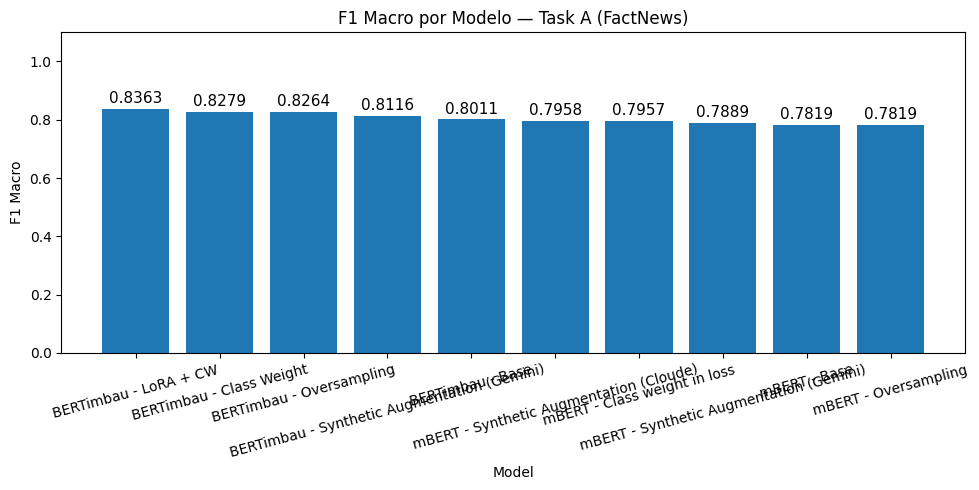

In [17]:
import matplotlib.pyplot as plt

sorted_results = sorted(results.items(), key=lambda x: x[1]["f1_macro"], reverse=True)
model_names = [name for name, _ in sorted_results]
f1_values   = [v["f1_macro"] for _, v in sorted_results]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(model_names, f1_values)

for bar, val in zip(bars, f1_values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{val:.4f}", ha="center", va="bottom", fontsize=11)

ax.set_ylim(0, 1.1)
ax.set_xlabel("Model")
ax.set_ylabel("F1 Macro")
ax.set_title("F1 Macro por Modelo — Task A (FactNews)")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}f1_macro_comparison.png", dpi=150)
plt.show()